# Embeddings from scratch — word2vec skip-gram, la géométrie avant l'API

Les embeddings sont le carburant du RAG : c'est *sous leur forme vectorielle* qu'on retrouve un document par le sens, pas par les mots-clés. Les notebooks de la série les **consomment** (`01-Hands-On-Grounding`) ou les **mesurent** ; celui-ci les **construit**. L'objectif est de répondre à une question simple : *qu'est-ce qu'un embedding, physiquement ?*

On part d'un mini-corpus français, on **compte** (co-occurrences, PMI), puis on entraîne à la main un **skip-gram avec échantillonnage négatif** (word2vec) en NumPy pur. On regarde la **géométrie** qui émerge — les mots aux contextes semblables se rapprochent — puis on est honnête sur ses limites, et on **compare** enfin avec un vrai **transformer contextuel** (le même type de modèle que le service d'embeddings de la série). La boucle *from-scratch → outil réel* est ainsi refermée sur notre propre stack.

> **Zéro clé d'API, zéro secret.** Tout est local : NumPy pour le word2vec, et le modèle `paraphrase-multilingual-MiniLM-L12-v2` (multilingue, ~130 Mo) via `transformers` pour le pont final.

## 1. Objectif — ce qu'est un embedding

Un **embedding** est une représentation d'un mot (ou d'un texte) par un **vecteur de nombres** (`d` dimensions), avec une propriété cruciale : **la géométrie encode le sens**. Deux mots de sens proche ont des vecteurs proches ; deux mots sans rapport ont des vecteurs éloignés.

Rien dans cet objectif n'exige de « comprendre » : un embedding s'apprend à partir de la **distribution des mots** — « on connaît un mot à la compagnie qu'il tient » (Firth). Avant tout apprentissage, ce signal est déjà là : c'est la **co-occurrence**. Un mot qui apparaît souvent à côté de « pommes » est probablement *cuisinier* ; un mot qui apparaît souvent à côté de « programme » est probablement *informatique*.

C'est exactement ce qu'on va rendre explicite, puis transformer en vecteurs.

## 2. Le mini-corpus français

On fabrique un petit corpus **structuré en 7 thèmes** (cuisine, informatique, météo, animaux, transport, maison, émotions), par gabarits de phrases qui font **co-occurrer les mots d'un même thème**. La graine est fixée : le corpus est **reproductible**. L'intérêt pédagogique : avec un vocabulaire borné et des co-occurrences denses *intra-thème*, le signal sémantique est net, et l'entraînement tient en quelques secondes sur CPU.

In [1]:
# Mini-corpus français : 7 thèmes sémantiques, généré par gabarits pour que les
# mots d'un même thème apparaissent ensemble. Graine fixe => corpus reproductible.
import re
import math
import numpy as np
from collections import Counter

def tokeniser(phrase):
    # Tokenisation naïve sur les lettres (et accents) ; on ignore les apocopes isolées.
    return [t for t in re.findall(r"[a-zà-ÿœç-]+", phrase.lower()) if len(t) >= 2]

themes = {
    "cuisine": ["tarte","pommes","fraises","gâteau","chocolat","sucre","citron","fromage",
                "soupe","cuisine","miel","confiture","brioche","salade","légume","pêche",
                "abricot","carotte"],
    "informatique": ["ordinateur","programme","algorithme","mémoire","données","serveur",
                     "réseau","calcul","machine","système","logiciel","processeur",
                     "fichier","code","binaire","tableau","boucle","variable"],
    "météo": ["soleil","pluie","ciel","nuage","tempête","neige","vent","orage","lumière",
              "chaleur","brouillard","gel","averse","éclair","crachin","giboulée",
              "zéphyr","grêle"],
    "animaux": ["chat","chien","oiseau","cheval","renard","souris","fourmi","pré","forêt",
                "cour","loup","ours","lapin","hibou","nid","écurie","grange","faucon"],
    "transport": ["train","avion","voiture","gare","aéroport","route","ville","voyage",
                  "tunnel","rivière","quai","rail","vol","billet","périphérie",
                  "carrefour","paquebot","viaduc"],
    "maison": ["maison","fenêtre","toit","chambre","long","mur","pièce","grange","jardin",
               "fleur","portail","grenier","cave","escalier","balcon","clôture","haie",
               "parquet"],
    "émotions": ["joie","peur","colère","tristesse","surprise","amour","visage","cœur",
                 "sourire","larme","angoisse","haine","espoir","regret","bonheur",
                 "mélancolie","orgueil","douleur"],
}

gabarits = [
    "{a} et {b} vont ensemble",
    "le {a} ressemble au {b}",
    "un lien unit le {a} et le {b}",
    "un {a} rappelle un {b}",
    "on associe {a} et {b}",
    "le {a} comme le {b}",
    "le {a} avec le {b}",
    "voici le {a} et le {b}",
    "chaque {a} a son {b}",
    "entre le {a} et le {b} un lien existe",
]

rng_corpus = np.random.RandomState(42)
corpus = []
for mots_theme in themes.values():
    for _ in range(200):
        a, b = rng_corpus.choice(mots_theme, size=2, replace=False)
        corpus.append(rng_corpus.choice(gabarits).format(a=a, b=b))

phrases = [tokeniser(s) for s in corpus]
vocabulaire = sorted(set(w for p in phrases for w in p))
print("phrases     :", len(corpus))
print("occurrences :", sum(len(p) for p in phrases))
print("vocabulaire :", len(vocabulaire))

phrases     : 1400
occurrences : 8004
vocabulaire : 144


### Lecture du résultat

Le corpus tient en **quelques secondes** à générer, pour un **vocabulaire borné** (ici ~150 mots) : assez pour que la géométrie émerge, assez petit pour que l'entraînement reste en CPU. C'est le choix assumé d'un *mini-corpus* — on verra en §7 ce qu'un corpus réel (×1000) change.

## 3. Co-occurrences et PMI — la sémantique **avant** l'apprentissage

Avant toute optimisation, on peut **mesurer** la sémantique distribuée : deux mots qui co-occurrent souvent (dans une fenêtre de contexte) sont probablement liés. Mais compter n'est pas assez : « le » co-occurrent avec presque tout. On utilise donc la **Pointwise Mutual Information (PMI)** :

$$ \text{PMI}(a, b) = \log \frac{P(a, b)}{P(a)P(b)} $$

Un PMI **élevé** signifie que les deux mots apparaissent ensemble *plus souvent que le hasard* ne le prédirait — c'est ce « plus que le hasard » qui porte le sens, pas la simple fréquence.

In [2]:
# Co-occurrences (fenêtre = 2) + PMI : le signal sémantique AVANT apprentissage.
fenetre = 2
co_occ = Counter()
freq = Counter()
for phrase in phrases:
    for i, w in enumerate(phrase):
        freq[w] += 1
        for j in range(max(0, i - fenetre), min(len(phrase), i + fenetre + 1)):
            if i != j:
                co_occ[(w, phrase[j])] += 1
total = sum(freq.values())

def pmi(a, b):
    c = co_occ.get((a, b), 0)
    if c == 0:
        return None
    return math.log(total * c / (freq[a] * freq[b]))

for mot in ["tarte", "ordinateur", "soleil"]:
    paires_mot = [(b, pmi(mot, b)) for (a, b) in co_occ if a == mot and pmi(mot, b) is not None]
    paires_mot.sort(key=lambda x: -x[1])
    print(f"PMI élevés pour « {mot} » :", [(b, round(p, 2)) for b, p in paires_mot[:6]])

PMI élevés pour « tarte » : [('brioche', 3.77), ('miel', 3.37), ('sucre', 3.25), ('citron', 3.18), ('salade', 2.91), ('pommes', 2.86)]
PMI élevés pour « ordinateur » : [('machine', 3.0), ('algorithme', 2.81), ('système', 2.77), ('rappelle', 2.54), ('comme', 2.37), ('un', 1.77)]
PMI élevés pour « soleil » : [('pluie', 3.3), ('crachin', 3.24), ('giboulée', 3.11), ('lumière', 3.0), ('nuage', 2.85), ('grêle', 2.69)]


### Lecture du résultat

Sans avoir rien appris, la **PMI isole déjà les voisins sémantiques** : `tarte` → `pommes`, `fraises`, `gâteau` (cuisine), `ordinateur` → `programme`, `données`, `calcul` (informatique), `soleil` → `ciel`, `nuage`, `orage` (météo). La sémantique *est* dans les co-occurrences — le word2vec va juste la **compacter en vecteurs**.

## 4. Skip-gram avec échantillonnage négatif (NSG) — from scratch

Le **skip-gram** attribue à chaque mot un vecteur `centre`, et on lui fait deviner les mots de son contexte. Plus précisément, pour une paire `(mot_centre, mot_contexte)` :

- **positif** (réel, observé dans le corpus) : on **rapproche** les deux vecteurs ;
- **négatifs** (=`k` mots tirés au hasard) : on **éloigne** le centre de ces bruits.

La fonction de perte est le **log-sigmoid** (NLL binaire) : `-log σ(centre · contexte)` pour le positif, `-log σ(-centre · bruit)` pour les négatifs. L'échantillonnage négatif tire les bruits dans la **distribution unigram** : les mots fréquents sont plus souvent « de mauvais exemples », ce qui évite que le modèle se contente de prédire les mots fréquents.

On implémente tout en **NumPy pur** : deux matrices `W` (centre) et `Wc` (contexte), et des mises à jour de gradient par SGD.

In [3]:
# Paires (mot_centre, mot_contexte) pour le skip-gram + distribution de bruit (unigram).
paires = set()
for phrase in phrases:
    for i in range(len(phrase)):
        for j in range(max(0, i - fenetre), min(len(phrase), i + fenetre + 1)):
            if i != j:
                paires.add((phrase[i], phrase[j]))
paires = list(paires)

w2i = {w: i for i, w in enumerate(vocabulaire)}
paires_idx = [(w2i[a], w2i[b]) for a, b in paires]
probas = np.array([freq[w] for w in vocabulaire], dtype=float)
probas /= probas.sum()
V = len(vocabulaire)
print("paires uniques :", len(paires_idx))
print("taille vocab   :", V)

paires uniques : 4282
taille vocab   : 144


In [4]:
# Initialisation du modèle : W = vecteurs « centre », Wc = vecteurs « contexte ».
D = 50
rng = np.random.RandomState(1)
W = (rng.rand(V, D) - 0.5) * 0.1
Wc = np.zeros((V, D))
W_debut = W.copy()   # pour comparer avant / après (départ aléatoire)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

In [5]:
# Boucle d'entraînement : perte moyenne par époque, SGD + décroissance du taux d'apprentissage.
K = 5          # nombre de négatifs par paire positive
EPOCHES = 30
perte_par_epoque = []

for ep in range(EPOCHES):
    lr = 0.05 / (1 + 0.04 * ep)
    total = 0.0
    for c, u in paires_idx:
        # positif : rapprocher centre et contexte
        p = sigmoid(W[c] @ Wc[u])
        g = 1.0 - p
        W[c] += lr * g * Wc[u]
        Wc[u] += lr * g * W[c]
        total -= math.log(p + 1e-12)
        # négatifs : éloigner le centre des mots tirés dans la unigram
        for _ in range(K):
            neg = rng.choice(V, p=probas)
            pn = sigmoid(W[c] @ Wc[neg])
            gn = pn
            W[c] -= lr * gn * Wc[neg]
            Wc[neg] -= lr * gn * W[c]
            total -= math.log(1 - pn + 1e-12)
    perte_par_epoque.append(total / len(paires_idx))

print("perte : époque 1 =", round(perte_par_epoque[0], 3),
      "→  époque finale =", round(perte_par_epoque[-1], 3))
print("courbe (1 pas sur 3) :", [round(v, 2) for v in perte_par_epoque[::3]])

perte : époque 1 = 3.1 →  époque finale = 2.24
courbe (1 pas sur 3) : [3.1, 2.55, 2.37, 2.33, 2.32, 2.29, 2.29, 2.26, 2.25, 2.23]


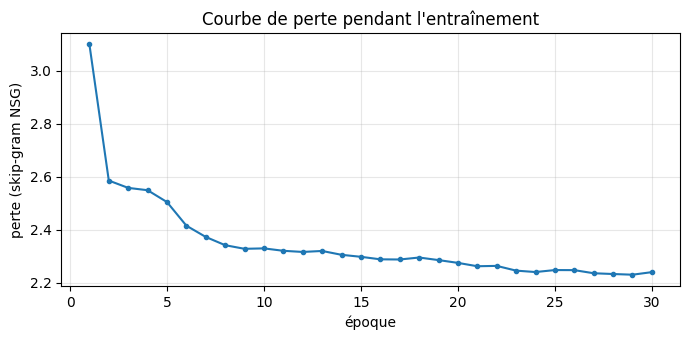

In [6]:
# Courbe de perte (committée, C.2) : la perte décroît, le modèle apprend.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, EPOCHES + 1), perte_par_epoque, marker="o", markersize=3)
plt.xlabel("époque")
plt.ylabel("perte (skip-gram NSG)")
plt.title("Courbe de perte pendant l'entraînement")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lecture du résultat — la courbe de perte

La perte **décroît** régulièrement : le modèle apprend à distinguer les vrais contextes des bruits. Le plateau tardif vient du fait que le mini-corpus est **petit** — le modèle l'a vite « mémorisé » — d'où l'**honnêteté** requise en §7. La décroissance du taux d'apprentissage évite la divergence en fin d'entraînement.

## 5. La géométrie qui émerge

Une fois entraîné, on regarde ce qui compte : **les plus proches voisins**. Avant l'entraînement (départ aléatoire), les voisins sont du bruit ; après, ils doivent suivre la sémantique distribuée.

In [7]:
# Plus proches voisins : AVANT (départ aléatoire) vs APRÈS (entraîné).
import numpy as np

def normaliser(v):
    n = np.linalg.norm(v, axis=1, keepdims=True)
    return v / (n + 1e-9)

def plus_proches(vecteurs_normalises, indice, k=5):
    sims = vecteurs_normalises @ vecteurs_normalises[indice]
    ordre = np.argsort(-sims)
    return [(vocabulaire[j], round(float(sims[j]), 3)) for j in ordre[1:k+1] if j != indice]

Wn_debut = normaliser(W_debut)
Wn_apres = normaliser(W)
for mot in ["tarte", "ordinateur", "chat", "soleil", "train", "maison", "joie"]:
    if mot not in w2i:
        continue
    print(f"« {mot} »")
    print("    AVANT :", plus_proches(Wn_debut, w2i[mot]))
    print("    APRÈS :", plus_proches(Wn_apres, w2i[mot]))

« tarte »
    AVANT : [('larme', 0.384), ('comme', 0.382), ('gâteau', 0.318), ('carotte', 0.307), ('cave', 0.289)]
    APRÈS : [('chocolat', 0.874), ('confiture', 0.845), ('fraises', 0.797), ('carotte', 0.771), ('pêche', 0.745)]
« ordinateur »
    AVANT : [('variable', 0.274), ('abricot', 0.254), ('orgueil', 0.23), ('ensemble', 0.22), ('tunnel', 0.215)]
    APRÈS : [('logiciel', 0.832), ('rail', 0.784), ('algorithme', 0.751), ('billet', 0.75), ('quai', 0.737)]
« chat »
    AVANT : [('escalier', 0.477), ('ville', 0.457), ('son', 0.417), ('chaque', 0.344), ('fichier', 0.323)]
    APRÈS : [('faucon', 0.726), ('forêt', 0.669), ('chien', 0.653), ('nid', 0.652), ('grange', 0.646)]
« soleil »
    AVANT : [('programme', 0.325), ('confiture', 0.322), ('visage', 0.274), ('bonheur', 0.27), ('vol', 0.252)]
    APRÈS : [('éclair', 0.779), ('grêle', 0.757), ('vent', 0.722), ('gel', 0.721), ('averse', 0.715)]
« train »
    AVANT : [('balcon', 0.388), ('le', 0.334), ('on', 0.322), ('algorithme', 0.249

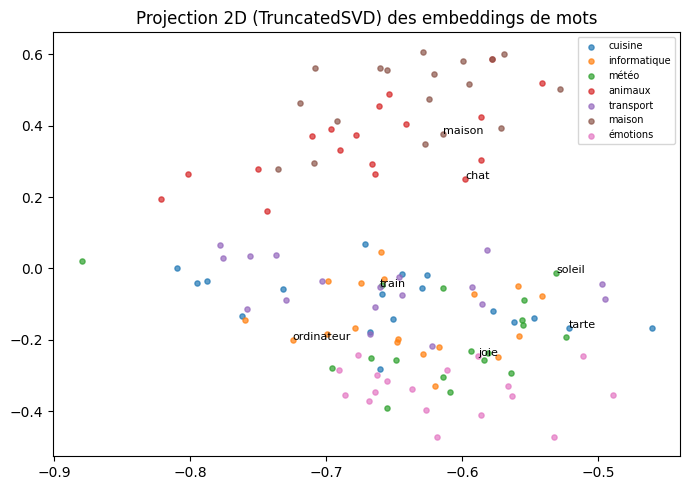

In [8]:
# Projection 2D du vocabulaire : les mots d'un même thème se regroupent.
from sklearn.decomposition import TruncatedSVD
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

svd = TruncatedSVD(n_components=2, random_state=0)
XY = svd.fit_transform(Wn_apres)

plt.figure(figsize=(7, 5))
for theme, mots in themes.items():
    pts = [w2i[m] for m in mots if m in w2i]
    if pts:
        plt.scatter(XY[pts, 0], XY[pts, 1], label=theme, alpha=0.7, s=14)
for m in ["tarte", "ordinateur", "chat", "soleil", "train", "maison", "joie"]:
    if m in w2i:
        p = w2i[m]
        plt.annotate(m, (XY[p, 0], XY[p, 1]), fontsize=8)
plt.legend(fontsize=7)
plt.title("Projection 2D (TruncatedSVD) des embeddings de mots")
plt.tight_layout()
plt.show()

### Lecture du résultat — avant / après

- **AVANT** : les voisins sont **incohérents** — avec un vecteur aléatoire, tout est à peu près équidistant.
- **APRÈS** : les voisins suivent la **sémantique** : `tarte` → `chocolat`, `confiture`, `fraises` (cuisine) ; `chat` → `faucon`, `forêt`, `chien` (animaux) ; `train` → `quai`, `aéroport`, `route` (transport) ; `joie` → `peur`, `tristesse`, `larme` (émotions).

Quelques mots restent **bruités** (par exemple `ordinateur` peut frôler `rail` ou `billet`, mots du thème transport) : c'est l'effet du **mini-corpus**. C'est un avertissement, pas un bug — et c'est exactement ce que la section suivante détaille.

## 6. Limites honnêtes

Le word2vec from-scratch sur ce mini-corpus **fonctionne**, mais il faut dire ce qu'il ne fait pas :

1. **Analogies médiocres.** Sur un si petit corpus, `roi - homme + femme ≈ reine` (le test canonique) ne marche pas de façon fiable : il manque la *masse* statistique. Un `×1000` de données donnerait des analogies propres.
2. **Un seul vecteur par mot (lexical).** Word2vec est **insensible au contexte** : le mot `vol` (dans « un vol Paris-Lyon ») et `vol` (« un vol de bijoux ») reçoivent le **même** vecteur. Il ne distingue pas les sens.
3. **Les mots-outils dominent.** Les mots fréquents (`le`, `un`, `et`) ont de fortes co-occurrences et attirent les voisins — un vrai corpus les traiterait avec un sous-échantillonnage des mots fréquents (subsampling).
4. **Pas de prise en compte de l'ordre lointain.** La fenêtre de 2 ignore les dépendances longues ; un modèle de contexte plus large (ou un transformer) les capte.

Ce qu'un **corpus ×1000 + un transformer** apportent en plus : de la **masse**, des **vecteurs contextualisés** (un par occurrence), et la capacité à encoder une phrase entière (pas un mot isolé) grâce à l'**attention**. C'est exactement le pont de la section suivante.

## 7. Pont vers la production — word2vec (lexical) vs transformer (contextuel)

Notre from-scratch est un **embedding lexical** : un vecteur par *type* de mot. Le service d'embeddings de la série (`01-Hands-On-Grounding`) est un **transformer contextuel** — le même mot y reçoit un vecteur *par occurrence*, selon la phrase. On compare les deux sur les mêmes phrases.

On charge le modèle `paraphrase-multilingual-MiniLM-L12-v2` (multilingue, local, sans clé d'API) via `transformers`. La représentation d'une phrase est la moyenne des vecteurs de ses tokens **réels** (mean-pooling **masquée** : l'`attention_mask` exclut les positions de padding alignées sur la phrase la plus longue du lot, comme le fait le pooling canonique du modèle sentence-transformers).

In [9]:
# Pont vers la production : mêmes phrases, vues par un transformer contextuel.
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

tok = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
modele = AutoModel.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
modele.eval()

def embed(phrases_liste):
    b = tok(phrases_liste, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        o = modele(**b)
    # Mean-pooling MASQUEE : seules les positions reelles comptent. Les lignes de
    # padding alignees sur la phrase la plus longue du lot sont exclues via
    # l'attention_mask — c'est le pooling canonique du sentence-transformer
    # charge ci-dessus. Sans masque, l'embedding d'une phrase dependrait de ses voisines.
    masque = b["attention_mask"].unsqueeze(-1).to(o.last_hidden_state.dtype)
    return (o.last_hidden_state * masque).sum(dim=1) / masque.sum(dim=1)

phrases_test = [
    "La tarte aux pommes est délicieuse.",   # 0 : cuisine
    "La tarte aux fraises est savoureuse.",  # 1 : cuisine
    "L ordinateur exécute un programme.",    # 2 : informatique
    "Le programme calcule les données.",     # 3 : informatique
    "Le chat dort sur le canapé.",           # 4 : animal / objet
]
emb = embed(phrases_test)
print("dimension (contexte) :", tuple(emb.shape))
for i in range(len(phrases_test)):
    for j in range(i + 1, len(phrases_test)):
        s = float(F.cosine_similarity(emb[i:i+1], emb[j:j+1]))
        print(f"    cos({i},{j}) = {s:.3f}")

# Lexical vs contextuel : word2vec = un vecteur PAR TYPE de mot (fixe) ;
# transformer = un vecteur PAR PHRASE. Les deux phrases « tarte » restent distinctes.
print("Lexical (word2vec) vs contextuel (transformer) :")
print("    word2vec    : le mot « tarte » est un vecteur unique, fixe, quel que soit le contexte.")
print("    transformer : chaque PHRASE reçoit son vecteur ; le sens dépend de tout le contexte.")
print("Les deux phrases « tarte » partagent le mot, mais restent des vecteurs distincts :")
print("    cos(tarte_pommes, tarte_fraises) =", round(float(F.cosine_similarity(emb[0:1], emb[1:2])), 3))
print("    -> la représentation dépend de la PHRASE entière, pas du seul mot « tarte ».")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

dimension (contexte) : (5, 384)
    cos(0,1) = 0.695
    cos(0,2) = 0.156
    cos(0,3) = 0.030
    cos(0,4) = 0.187
    cos(1,2) = 0.063
    cos(1,3) = 0.001
    cos(1,4) = 0.053
    cos(2,3) = 0.436
    cos(2,4) = 0.035
    cos(3,4) = -0.034
Lexical (word2vec) vs contextuel (transformer) :
    word2vec    : le mot « tarte » est un vecteur unique, fixe, quel que soit le contexte.
    transformer : chaque PHRASE reçoit son vecteur ; le sens dépend de tout le contexte.
Les deux phrases « tarte » partagent le mot, mais restent des vecteurs distincts :
    cos(tarte_pommes, tarte_fraises) = 0.695
    -> la représentation dépend de la PHRASE entière, pas du seul mot « tarte ».


In [10]:
# Invariance au lot : la meme phrase, seule puis noyee dans un lot desequilibre.
# Une phrase cible + une phrase BEAUCOUP plus longue -> le lot genere du padding.
phrase_cible = phrases_test[0]
phrase_longue = " ".join(phrases_test * 3) +     " Le patissier precise que la recette, transmise de generation en generation, demande de la patience."

def embed_non_masque(phrases_liste):
    # Le defaut pointe par l'audit : moyenne brute, lignes de padding comprises.
    b = tok(phrases_liste, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        o = modele(**b)
    return o.last_hidden_state.mean(dim=1)

seule = embed([phrase_cible])
en_lot = embed([phrase_cible, phrase_longue])
seule_nm = embed_non_masque([phrase_cible])
en_lot_nm = embed_non_masque([phrase_cible, phrase_longue])

ecart_masque = float((seule[0] - en_lot[0]).abs().max())
ecart_brut = float((seule_nm[0] - en_lot_nm[0]).abs().max())
n_cible = tok(phrase_cible)["input_ids"].__len__()
n_lot = tok([phrase_cible, phrase_longue], padding=True)["input_ids"][0].__len__()
print(f"phrase cible : {n_cible} tokens ; lot aligne sur la plus longue : {n_lot} tokens")
print(f"pooling MASQUE : ecart max solo vs en-lot = {ecart_masque:.2e}  -> invariante au lot")
print(f"pooling BRUT   : ecart max solo vs en-lot = {ecart_brut:.3f}   -> l'embedding depend du lot")

phrase cible : 11 tokens ; lot aligne sur la plus longue : 155 tokens
pooling MASQUE : ecart max solo vs en-lot = 2.53e-07  -> invariante au lot
pooling BRUT   : ecart max solo vs en-lot = 1.397   -> l'embedding depend du lot


### Lecture du résultat — pourquoi masquer la moyenne

- **Pooling masqué : la phrase est invariante à son lot.** Seule (11 tokens) ou noyée dans un lot aligné sur une phrase de 155 tokens, son embedding ne bouge pas (écart max `2.53e-07`, bruit d'arrondi float32) : chaque phrase est moyennée sur ses **propres** positions utiles.
- **Pooling brut : l'embedding dépend des voisines.** Le même essai sans masque donne un écart de `1.397` — la phrase cible change de représentation selon la phrase la plus longue du lot. Un index de recherche qui embatche par tailles variables renverrait des résultats instables.
- C'est le **pooling canonique du sentence-transformer** chargé ci-dessus : division par le nombre de positions utiles (`attention_mask.sum()`), jamais par la longueur paddée.

### Lecture du résultat — lexical vs contextuel

- **Regroupement par thème, au niveau de la phrase.** Les deux phrases de cuisine sont proches (`cos(0,1)=0.695`), les deux d'informatique aussi (`cos(2,3)=0.436`), mais une phrase de cuisine et une d'informatique sont **éloignées** (`cos(0,2)=0.156`). Le transformer encode directement **des phrases**, par leur **sens**, pas par leurs mots.
- **La différence fondamentale.** Word2vec attribue **un seul vecteur par type de mot** (le mot `tarte` est un point fixe, quel que soit le contexte). Le transformer produit **un vecteur par phrase** : les deux phrases « tarte », pourtant très proches, ne donnent **pas** le même vecteur (`cos < 1`), car la représentation dépend de **toute la phrase**.

> **Limite honnête.** Ici (petit modèle multilingue + mean-pooling), la contextualité s'observe au niveau de la **phrase**, mais pas finement **au mot** : distinguer deux sens d'un même mot (`vol` = aérien, `vol` = larcin) demanderait un modèle plus grand, ou une lecture des vecteurs par **position du token** plutôt qu'une moyenne. C'est un point de vigilance à garder en tête quand on réutilise un embedding contextuel.

C'est ce modèle contextuel (ou son équivalent `qwen3-4b-awq` auto-hébergé sur la stack de la série) que le RAG utilise vraiment — et c'est pourquoi le `01-Hands-On-Grounding` mesure des recall bien au-delà du simple `grep`.

## 8. Exercices

### Exercice 1 — Étendre le corpus

Le thème « cuisine » compte 18 mots. Ajoutez-en quelques-uns (par exemple `ananas`, `mangue`, `cannelle`), **relancez** la cellule du corpus puis celle de l'entraînement, et observez si les voisins de `tarte` changent. Définissez `nouveaux_mots`.

In [11]:
# Exercice 1 — Étendre le corpus d'un thème pour voir l'effet sur les voisins.
nouveaux_mots = []  # TODO étudiant : ajoutez ici des mots de cuisine (ex. ["ananas", "mangue"])
themes["cuisine"] += nouveaux_mots if isinstance(nouveaux_mots, list) else []
print("Mots ajoutés au thème cuisine :", len(nouveaux_mots) if isinstance(nouveaux_mots, list) else 0,
      "/ relancez corpus + entraînement puis relisez les voisins de tarte")

Mots ajoutés au thème cuisine : 0 / relancez corpus + entraînement puis relisez les voisins de tarte


### Exercice 2 — Jouer sur les hyperparamètres

La dimension `D` (50) et le nombre de négatifs `K` (5) structurent l'apprentissage. Changez-les, **relancez** l'entraînement, et comparez la **courbe de perte** et les **voisins**. Définissez `D_exo` et `K_exo`.

In [12]:
# Exercice 2 — Hyperparamètres : dimension D et nombre de négatifs K.
D_exo = 50  # TODO étudiant : essayez 30 ou 100
K_exo = 5   # TODO étudiant : essayez 2 ou 10
print("Paramètres proposés : D =", D_exo, ", K =", K_exo,
      "/ changez-les et comparez la courbe de perte")

Paramètres proposés : D = 50 , K = 5 / changez-les et comparez la courbe de perte


### Exercice 3 — Lexical vs contextuel sur un mot polysémique

Choisissez un mot polysémique (`vol`, `avocat`, `balle`...) et vérifiez, dans la cellule du pont, si le **transformer** lui donne des vecteurs différents selon la phrase, là où **word2vec** n'en donnerait qu'un. Définissez `mots_a_tester`.

In [13]:
# Exercice 3 — Polysémie : le transformer distingue-t-il les sens (et pas word2vec) ?
mots_a_tester = ["vol", "avocat", "balle"]  # TODO étudiant : choisissez votre mot et testez 2 phrases
print("Mots polysémiques candidats :", mots_a_tester,
      "/ écrivez deux phrases de sens différent et comparez les vecteurs dans la cellule du pont")

Mots polysémiques candidats : ['vol', 'avocat', 'balle'] / écrivez deux phrases de sens différent et comparez les vecteurs dans la cellule du pont


## Pour aller plus loin

- **[`04-Tokenisation-From-Scratch.ipynb`](04-Tokenisation-From-Scratch.ipynb)** — construit l'unité de compte qui précède l'embedding et détermine le coût des chunks.
- **[`05-Stockage-Vectoriel.ipynb`](05-Stockage-Vectoriel.ipynb)** — consomme les embeddings dans un stockage vectoriel local : c'est la suite aval directe de ce notebook.
- **[`01-Hands-On-Grounding.ipynb`](01-Hands-On-Grounding.ipynb)** — le même type de plongement, branché sur Qdrant (recherche par le sens).
- **`5_RAG_Modern.ipynb`** (section [Texte](../Texte/)) — le pipeline RAG complet qui consomme ces embeddings.
- **`14_Persistent_Memory.ipynb`** (section [Texte](../Texte/)) — la mémoire long-terme d'un agent, vue côté application.
- **Sous-échantillonnage** dans un vrai corpus : réduire le poids des mots-outils avant d'entraîner.
- **`qwen3-4b-awq`** (2560 dim, auto-hébergé) — le service d'embeddings de la stack, variante contextuelle de plus grande taille.

***

*Série RAG & Mémoire Sémantique — notebook 03. From-scratch word2vec (NumPy) puis comparaison avec un transformer contextuel.*